In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use(r'/Users/dq219/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Research/utilities/mplstyle')

import matplotlib as mpl
import time as time

colorsBlue = ['#b3e5fc', '#0091ea']
colorsRed = ['#f18e86', '#e83b47']
colorsYellow = ['#fec787', '#fb9d32']
colorsPurple = ['#d69bc5' ,'#a8509f']
colorsGreyOrange = ['#c3c3c3', '#f8a834']
colors = [colorsBlue, colorsRed, colorsYellow, colorsPurple, colorsGreyOrange]

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [4]:
from utils.dataset import Gen2DDataset
from utils.models import modelFull, modelModular, modelBottleNeck

In [5]:
# generate 3 random functions

np.random.seed(42)

lims = [1, 1]
grid_size = 0.25
totaln = int((2 / grid_size) **2)
ns = np.arange(totaln)
np.random.shuffle(ns)
shown_n = ns[:int(totaln * 0.8)]
def Rmask(x, y):
    col_n = (x + 1) // grid_size
    row_n = (y + 1) // grid_size
    idx = int(col_n + row_n * (2 / grid_size))
    if idx in shown_n:
        return True
    else:
        return False

amps = 0.7 + 0.3 * np.random.rand(3) # * ((np.random.rand(encode_num) > 0) - 0.5)
fres = 0.8 + 2.8 * np.random.rand(3) # 0.4, 0.4 for N8 and N16
phis = 2 * np.pi * np.random.rand(3)
def funs(x, i):
    return amps[i] * np.sin(fres[i] * x + phis[i])

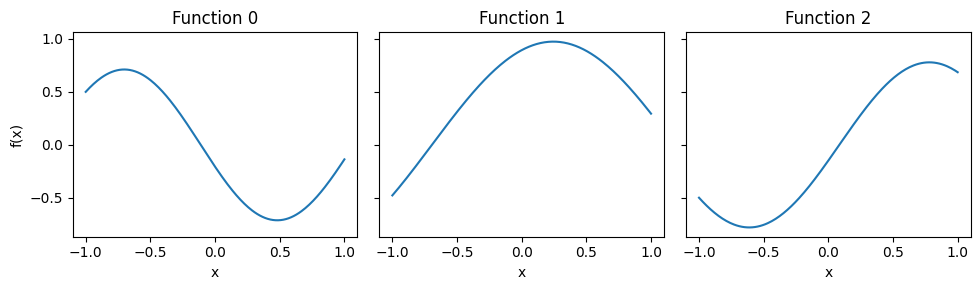

In [6]:
fig, axes = plt.subplots(1, 3, figsize = (10, 3), sharex = True, sharey = True)
for i in range(3):
    _ = np.linspace(-1, 1, 200)
    axes[i].plot(_, funs(_, i))
    axes[i].set_title(f'Function {i}')
    axes[i].set_xlabel('x')
axes[0].set_ylabel('f(x)')
# plt.savefig('plots/2D_gen_functions.pdf', bbox_inches = 'tight')
plt.tight_layout()

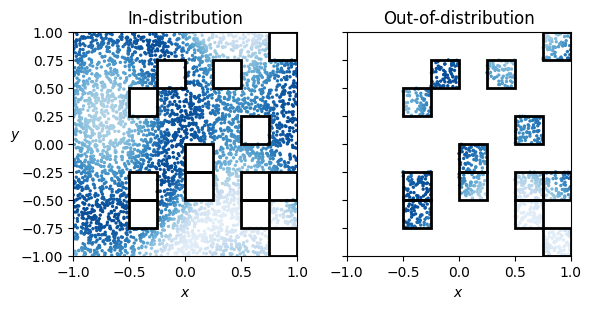

In [7]:
# generate ID and OOD datasets

masks = [lambda x, y: Rmask(x,y),
         lambda x, y: Rmask(x,y) == False]
sets = [Gen2DDataset(mask = masks[i], funs = funs) for i in range(len(masks))]

# visualise different mask regions
cmap = plt.cm.Blues
fig, axes = plt.subplots(1, len(masks), figsize = (6, 3), sharex = True, sharey = True)

for i in range(len(masks)):
    axes[i].set_aspect(1)
    xy, z = sets[i].get_all_data()
    xy, z = xy.numpy(), z.numpy().flatten()
    axes[i].scatter(xy[:, 0], xy[:, 1], c = z, s = 2, cmap = cmap, vmin = -1, vmax = 1)

    axes[i].set_xlabel('$x$')
    axes[i].set_xlim(-lims[0], lims[0])
    axes[i].set_ylim(-lims[1], lims[1])
    for j in range(totaln):
        if j in shown_n:
            continue
        col_n = (j % int(2 / grid_size))
        row_n = (j // int(2 / grid_size))
        rect = mpl.patches.Rectangle(( -1 + col_n * grid_size, -1 + row_n * grid_size), grid_size, grid_size,
                                     linewidth=2, edgecolor='black', facecolor='none')
        axes[i].add_patch(rect)
axes[0].set_ylabel('$y$', rotation = 0)
axes[0].set_title('In-distribution')
axes[1].set_title('Out-of-distribution')
plt.tight_layout()
# plt.savefig('fracs.pdf')

In [8]:
set_ID = sets[0]
set_OD = sets[1]
dataloader_ID = DataLoader(set_ID, batch_size = 64)
dataloader_OD = DataLoader(set_OD, batch_size = 64)

def simulate(idx, seed = None):
    if seed is None:
        seed = idx

    np.random.seed(seed)
    torch.manual_seed(seed)
    mode = ['modular', 'full', 'bottleneck'][idx]
    if mode == 'modular':
        model = modelModular()
    elif mode == 'full':
        model = modelFull()
    elif mode == 'bottleneck':
        model = modelBottleNeck()
    else:
        raise Exception('unknown mode')
    
    num_epochs = 2000
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr = 1e-3, weight_decay = 1e-4)
    total_params = sum(p.numel() for p in model.parameters())
    print('total model parameters is: {0}'.format(total_params))

    LOSS = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss_ID = 0.0
        for batch_idx, (inputs, targets) in enumerate(dataloader_ID):
            inputs, targets = inputs.to(device), targets.to(device).squeeze(-1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss_ID += loss.item()
            loss.backward()
            optimizer.step()
            
        avg_loss_ID = running_loss_ID / len(dataloader_ID)
        
        model.eval()  # Set the model to evaluation mode
        running_loss_OD = 0.0
        with torch.no_grad():  # No gradients needed during validation
            for inputs, targets in dataloader_OD:
                outputs = model(inputs)  # Forward pass
                loss = criterion(outputs, targets.squeeze(-1))  # Compute the validation loss
                running_loss_OD += loss.item()
        avg_loss_OD = running_loss_OD / len(dataloader_OD)
        
        LOSS.append([avg_loss_ID, avg_loss_OD])
        print(f"Epoch [{epoch+1}/{num_epochs}], ID Loss: {avg_loss_ID:.6f}, OOD Loss : {avg_loss_OD:.6f}, ratio : {avg_loss_OD / avg_loss_ID:.6f}", end = '\r')
    LOSS = np.array(LOSS)

    with open(f'results/loss_{mode}.npy', 'wb') as f:
        np.save(f, LOSS)

    torch.save(model, f'results/wts_{mode}.pth')
    

In [9]:
for i in range(3):
    simulate(i, seed = 42)

total model parameters is: 899
total model parameters is: 335370015, OOD Loss : 0.000018, ratio : 1.215148
total model parameters is: 115500023, OOD Loss : 0.000138, ratio : 6.0120061


In [10]:
modes = ['modular', 'full', 'bottleneck']
ccs = [colorsYellow, colorsRed, colorsPurple]

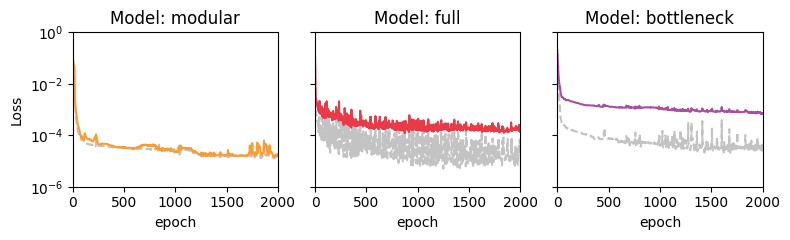

In [ ]:
fig, axes = plt.subplots(1, len(modes), figsize = (8, 2.5), sharex = True, sharey = True)
for i in range(len(modes)):
    with open(f'results/loss_{modes[i]}.npy', 'rb') as f:
        LOSS = np.load(f)
    axes[i].plot(LOSS[:, 0], color = colors[4][0], linestyle = 'dashed')
    axes[i].plot(LOSS[:, 1], color = ccs[i][1])
    axes[i].set_title(f'Model: {modes[i]}')
    axes[i].set_xlabel('epoch')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-6, 1e0)
axes[0].set_xlim(0, 2000)
axes[0].set_ylabel('Loss')
plt.tight_layout()
# plt.savefig('losses.pdf')

In [12]:
model = torch.load('results/wts_modular.pth', weights_only = False)

Text(0, 0.5, 'f(x)')

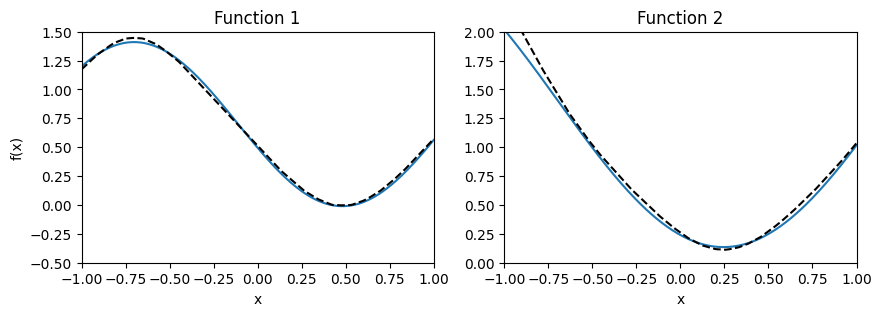

In [14]:
fig, axes = plt.subplots(1, 2, figsize = (10, 3))
a = [1, -1.3]
b = [0.7, 1.4]
for i in range(2):
    _ = np.linspace(-1, 1, 200)
    _y = funs(_, i)
    if i == 0:
        _z = model.mlp_02_x(torch.tensor(_.reshape(-1, 1), dtype = torch.float32)).detach().numpy()
    else:
        _z = model.mlp_02_y(torch.tensor(_.reshape(-1, 1), dtype = torch.float32)).detach().numpy()
    axes[i].plot(_, a[i] * _y + b[i])
    axes[i].plot(_, _z, color = 'black', linestyle = 'dashed')
    axes[i].set_title(f'Function {i+1}')
    axes[i].set_xlim(-1, 1)
    axes[i].set_xlabel('x')
axes[0].set_ylim(-0.5, 1.5)
axes[1].set_ylim(0, 2)
axes[0].set_ylabel('f(x)')
# plt.savefig('plots/mods.pdf')